<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/14-BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>BERTopic</h1>

En esta notebook usaremos [BERTopic](https://github.com/MaartenGr/BERTopic) para la tarea de Topic Modelling.

Este modelo usa un modelo de BERT para producir embeddings de documentos que luego son clusterizados y agrupados usando TF-IDF.

[Más información](https://maartengr.github.io/BERTopic/algorithm/algorithm.html)

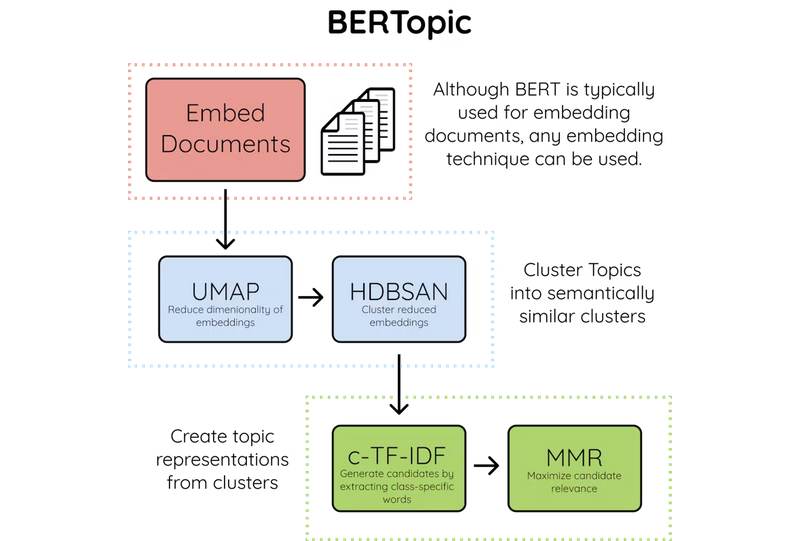

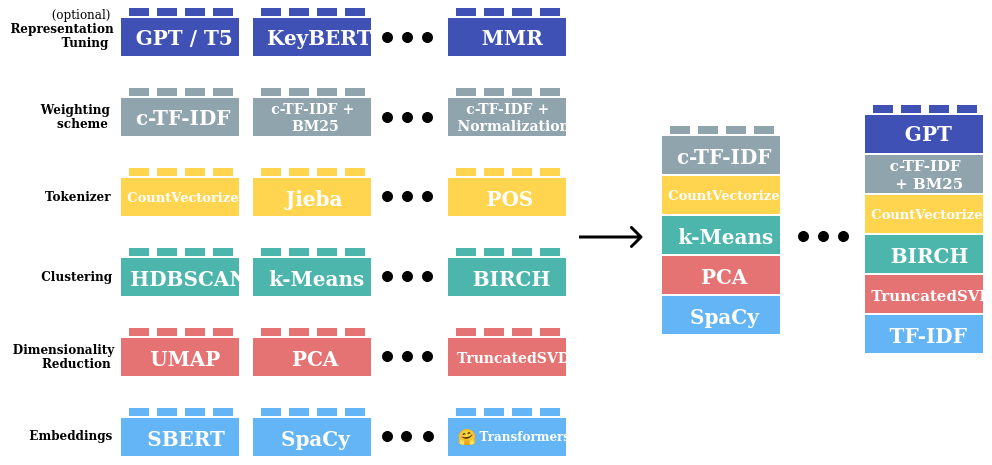

In [ ]:
!pip install -qq bertopic[visualization]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.3 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.6 MB/s eta 0:00:00


In [ ]:
!pip install -qq wordcloud

# Demostración básica

In [ ]:
from bertopic import BERTopic

## Corpus y preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import re
from string import punctuation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords',quiet=True)
nltk.download('punkt_tab',quiet=True)

stopwords = stopwords.words('english')
stopwords.extend(['from', 'subject', 're', 'edu', 'use'])
stopwords.extend(["n't","S","s"])

In [ ]:
from sklearn.datasets import fetch_20newsgroups

train_data = fetch_20newsgroups(subset='train',
                                remove=('headers', 'footers', 'quotes'),
                                categories=['sci.space', 'rec.sport.baseball','sci.med'],
                                random_state=642
                                )
test_data = fetch_20newsgroups(subset='test',
                                remove=('headers', 'footers', 'quotes'),
                                categories=['sci.space', 'rec.sport.baseball','sci.med'],
                                random_state=642
                               )

X_train_raw = train_data.data
y_train = train_data.target

X_test_raw = test_data.data
y_test = test_data.target

In [ ]:
X_raw = X_train_raw + X_test_raw
y = np.concatenate((y_train, y_test))

In [ ]:
docs = [re.sub(r'\d+', ' ', doc) for doc in X_raw]
docs = [re.sub(r'\n', ' ', doc) for doc in docs]
tokenized_docs = [[x for x in word_tokenize(doc) if x not in stopwords and x not in punctuation]
                        for doc in X_raw]
docs = [' '.join(doc) for doc in tokenized_docs]

In [ ]:
docs[50]

"Okay long shot My friend Robin recurring bouts mononucleosis-type symptoms regularly This going number years She 's seen number doctors six last count I think Most said either `` You mono '' `` You 're full 's nothing wrong '' One admitted idea wrong one claimed Epstein-Barr syndrome Now told EBS doctors even believe exists Obviously experience So 's story Is real Does medical profession believe real Has anyone success treating EBS Or something live Thanks assistance"

## Entrenamiento de BERTopic

El entrenamiento tarda alrededor de 4 minutos

In [ ]:
model = BERTopic(verbose=True)

topics, probabilities = model.fit_transform(docs)

2026-04-07 18:56:13,836 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2026-04-07 18:59:26,508 - BERTopic - Embedding - Completed ✓
2026-04-07 18:59:26,510 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 18:59:44,366 - BERTopic - Dimensionality - Completed ✓
2026-04-07 18:59:44,368 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 18:59:44,487 - BERTopic - Cluster - Completed ✓
2026-04-07 18:59:44,494 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 18:59:45,031 - BERTopic - Representation - Completed ✓


## Resultados

Cuando hay un tópico -1, este representa documentos *outliers*

In [ ]:
model.get_topic_freq()

,Topic,Count
0,0,892
3,-1,795
2,1,112
17,2,85
6,3,82
35,4,74
10,5,58
9,6,50
12,7,46
28,8,45


Número de tópicos:

In [ ]:
num_topics = len([x for x in model.get_topic_info()['Topic'] if x != -1])
num_topics

42

Información de los tópicos

In [ ]:
model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,795,-1_the_space_also_one,"[the, space, also, one, health, medical, it, t...",[GREAT post Martin Very informative well-balan...
1,0,892,0_game_year_team_games,"[game, year, team, games, last, baseball, woul...",[Tim Shippert recently posted summaries last y...
2,1,112,1_bullshit_curiousity_worden_mistake,"[bullshit, curiousity, worden, mistake, consis...","[BULLSHIT, Choose following answer, Just curio..."
3,2,85,2_hst_shuttle_reboost_station,"[hst, shuttle, reboost, station, orbit, missio...",[RIght HST sevicing mission listed 11 days lis...
4,3,82,3_lyme_disease_doctor_patients,"[lyme, disease, doctor, patients, medicine, me...",[Point 1 I 'm beginning see part disagreements...
5,4,74,4_sky_advertising_light_rights,"[sky, advertising, light, rights, would, billb...",[If idea goes 's thin end wedge Soon companies...
6,5,58,5_moon_prize_money_lunar,"[moon, prize, money, lunar, would, billion, kc...",[This turning 'what 's moonbase good I ought p...
7,6,50,6_msg_food_chinese_taste,"[msg, food, chinese, taste, flavor, foods, eat...",[If could tell one MSG restaurants bother If t...
8,7,46,7_venus_planet_earth_solar,"[venus, planet, earth, solar, surface, kilomet...",[Archive-name space/net Last-modified Date 93/...
9,8,45,8_spacecraft_probe_mars_command,"[spacecraft, probe, mars, command, data, launc...",[Forwarded Neal Ausman Galileo Mission Directo...


Información de los documentos

In [ ]:
model.get_document_info(docs).sample(5)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
1208,Archive-name typing-injury-faq/keyboards Versi...,-1,-1_the_space_also_one,"[the, space, also, one, health, medical, it, t...",[GREAT post Martin Very informative well-balan...,the - space - also - one - health - medical - ...,0.000000,False
2742,You need shoulder muscles push mower If much e...,22,22_pain_back_arm_neck,"[pain, back, arm, neck, muscles, massager, lef...",[I sure proper group post goes anyway About fi...,pain - back - arm - neck - muscles - massager ...,0.543146,False
2604,Candida Gordon I think best clinical trial can...,19,19_candida_yeast_yogurt_acidophilus,"[candida, yeast, yogurt, acidophilus, infectio...",[Elisabeth let 's set record straight nth time...,candida - yeast - yogurt - acidophilus - infec...,1.000000,False
781,There interesting opinion piece business secti...,14,14_space_tax_nasa_funds,"[space, tax, nasa, funds, program, ssf, reston...",[You totally forgot original post posted Allen...,space - tax - nasa - funds - program - ssf - r...,1.000000,False
229,I 35 recovering case Chicken Pox I contracted ...,-1,-1_the_space_also_one,"[the, space, also, one, health, medical, it, t...",[GREAT post Martin Very informative well-balan...,the - space - also - one - health - medical - ...,0.000000,False


## Visualización

In [ ]:
model.visualize_topics()

In [ ]:
model.visualize_barchart()

Veamos las palabras más importantes por cada tópico

In [ ]:
for k in range(num_topics):
    words = [x[0] for x in model.get_topic(k)]
    print(f"Topic {k}: {words}")

Topic 0: ['game', 'year', 'team', 'games', 'last', 'baseball', 'would', 'players', 'hit', 'he']
Topic 1: ['bullshit', 'curiousity', 'worden', 'mistake', 'consistently', 'hello', 'choose', 'answer', 'just', 'following']
Topic 2: ['hst', 'shuttle', 'reboost', 'station', 'orbit', 'mission', 'launch', 'the', 'design', 'cost']
Topic 3: ['lyme', 'disease', 'doctor', 'patients', 'medicine', 'medical', 'quack', 'patient', 'candida', 'would']
Topic 4: ['sky', 'advertising', 'light', 'rights', 'would', 'billboards', 'space', 'night', 'billboard', 'pollution']
Topic 5: ['moon', 'prize', 'money', 'lunar', 'would', 'billion', 'kc', 'much', 'contest', 'million']
Topic 6: ['msg', 'food', 'chinese', 'taste', 'flavor', 'foods', 'eat', 'sick', 'people', 'restaurant']
Topic 7: ['venus', 'planet', 'earth', 'solar', 'surface', 'kilometers', 'spacecraft', 'miles', 'space', 'the']
Topic 8: ['spacecraft', 'probe', 'mars', 'command', 'data', 'launch', 'april', 'satellite', 'mission', 'orbit']
Topic 9: ['larson

Similitud entre tópicos. Se calcula como la similitud coseno entre los centroides de los embeddings de los documentos de cada tópico

In [ ]:
model.visualize_heatmap()

Podemos obtener los tópicos de nuevos documentos

In [ ]:
topics, probs = model.transform(docs)

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2026-04-07 19:02:51,743 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-07 19:02:51,755 - BERTopic - Dimensionality - Completed ✓
2026-04-07 19:02:51,755 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-07 19:02:51,856 - BERTopic - Cluster - Completed ✓


Topics es el arreglo de tópicos

In [ ]:
print(len(topics))
print(np.unique(topics))
topics[:10]

2971
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41]


[np.int64(0),
 np.int64(36),
 np.int64(1),
 np.int64(-1),
 np.int64(-1),
 np.int64(-1),
 np.int64(16),
 np.int64(0),
 np.int64(0),
 np.int64(21)]

Esta representación tarda alrededor de 5 minutos. Es una reducción de dimensionalidad sobre los embeddings de documentos

In [ ]:
model.visualize_documents(docs, topics)

## Evaluación

Dado que tenemos etiquetas *ground-truth* podemos evaluar con Información Mutua

In [ ]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

print(f"AMI: {adjusted_mutual_info_score(y, topics)}")
print(f"ARI: {adjusted_rand_score(y, topics)}")

AMI: 0.4044975401986187
ARI: 0.3554565097792296


Podemos explorar las palabras más frecuentes con una wordcloud

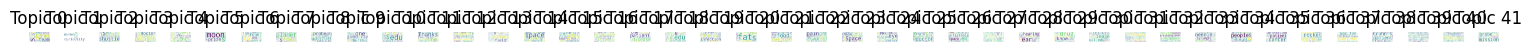

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

docs_idxs_per_topic = [np.where(np.array(topics) == i)[0] for i in range(num_topics)]

fig, axs = plt.subplots(1, num_topics, figsize=(15, 15))
for ax,j in zip(axs.flatten(),range(num_topics)):
    topic_docs = " ".join([docs[i] for i in docs_idxs_per_topic[j]])
    wc = WordCloud(background_color="white", max_words=2000).generate(topic_docs)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {j}")
    ax.axis("off")
fig.tight_layout()
fig.show()

# Detalles adicionales

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sentence_transformers import SentenceTransformer

# Modelo de embeddings
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Reducción de dimensionalidad: PCA en lugar de UMAP (default)
dim_model = PCA()

# Método de clustering: DBSCAN en lugar de HDBSCAN (default)
cluster_model = DBSCAN(eps=0.5, min_samples=2)

# Modelo BERTopic
new_model = BERTopic(
                    nr_topics=10,
                    embedding_model=embedding_model,
                    umap_model=dim_model,  # Se llama umap_model pero acepta cualquier reductor de dimensionalidad
                    hdbscan_model=cluster_model,  # Se llama hdbscan_model pero acepta cualquier clustering
                    language='english',
                    calculate_probabilities=False,
                    verbose=True
                )

# new_model = BERTopic(nr_topics=10)

new_topics, new_probabilities = new_model.fit_transform(docs)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-07 19:06:43,521 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2026-04-07 19:10:26,670 - BERTopic - Embedding - Completed ✓
2026-04-07 19:10:26,673 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 19:10:26,881 - BERTopic - Dimensionality - Completed ✓
2026-04-07 19:10:26,898 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 19:10:27,252 - BERTopic - Cluster - Completed ✓
2026-04-07 19:10:27,253 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-07 19:10:27,694 - BERTopic - Representation - Completed ✓
2026-04-07 19:10:27,696 - BERTopic - Topic reduction - Reducing number of topics
2026-04-07 19:10:27,712 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 19:10:28,140 - BERTopic - Representation - Completed ✓
2026-04-07 19:10:28,143 - BERTopic - Topic reduction - Reduced number of topics from 19 to 10


In [ ]:
from bertopic import BERTopic
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import re
from nltk.tokenize import word_tokenize

def calculate_coherence(topic_model, docs, topics, metric='u_mass', top_n=10):
    """
    Calcula coherencia usando gensim para tópicos de BERTopic

    Args:
        topic_model: Modelo BERTopic entrenado
        docs: Lista de documentos
        topics: Lista de tópicos asignados
        metric: 'u_mass', 'c_v', 'c_uci', 'c_npmi'
        top_n: Número de palabras top por tópico
    """
    # Tokenizar documentos
    tokenized_docs = [word_tokenize(doc) for doc in docs]

    # Crear diccionario de gensim
    dictionary = Dictionary(tokenized_docs)

    # Obtener tópicos de BERTopic (excluyendo outliers -1)
    topic_ids = [t for t in set(topics) if t != -1]

    # Extraer palabras top de cada tópico
    topic_words = []
    for topic_id in sorted(topic_ids):
        words = topic_model.get_topic(topic_id)
        if words:
            # Obtener solo las palabras (sin scores)
            top_words = [word for word, score in words[:top_n]]
            topic_words.append(top_words)

    if len(topic_words) == 0:
        return None, None

    # Calcular coherencia con gensim
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=metric
    )

    return coherence_model.get_coherence()

In [ ]:
calculate_coherence(new_model, docs, new_topics)

np.float64(-4.889353247611252)

In [ ]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

print(f"AMI: {adjusted_mutual_info_score(y, new_topics)}")
print(f"ARI: {adjusted_rand_score(y, new_topics)}")

AMI: 0.01225673506542871
ARI: 8.07724261180514e-07


In [ ]:
new_model.visualize_topics()

In [ ]:
new_model.visualize_heatmap()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Número de tópicos: 4/7


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Número de tópicos: 10/7


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Número de tópicos: 11/7


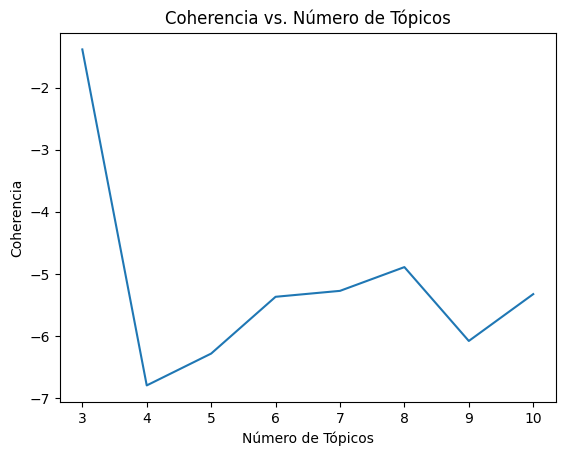

In [ ]:
import matplotlib.pyplot as plt

min_n, max_n = 3,10
num_topics = list(range(min_n,max_n+1))
coherence = []
for num in num_topics:
    model = BERTopic(nr_topics=num)
    new_topics, new_probabilities = model.fit_transform(docs)
    coherence.append(calculate_coherence(model, docs, new_topics))
    print(f"Número de tópicos: {num+1}/{max_n-min_n}")

plt.plot(num_topics, coherence)
plt.xlabel('Número de Tópicos')
plt.ylabel('Coherencia')
plt.title('Coherencia vs. Número de Tópicos')
plt.show()

# Representación de tópicos con etiquetas semánticas

Por defecto, BERTopic representa cada tópico como una lista de palabras clave (las *n* palabras con mayor peso en c-TF-IDF). Aunque útiles, estas listas no siempre son fáciles de interpretar.

BERTopic permite reemplazar esa representación por etiquetas más descriptivas usando distintos *representation models*. Aquí usamos **`KeyBERTInspired`**, que está incluido en BERTopic y no requiere dependencias externas.

### ¿Cómo funciona?

En lugar de seleccionar palabras solo por su frecuencia relativa (c-TF-IDF), `KeyBERTInspired` selecciona palabras cuyo **embedding** es cercano al embedding del tópico (centroide de los documentos del tópico) **y** lejano a los embeddings de los demás tópicos. Esto produce términos más discriminativos y semánticamente coherentes.

```
c-TF-IDF  →  palabras frecuentes y diferenciadoras (bag-of-words)
KeyBERT   →  palabras semánticamente cercanas al tópico (embedding space)
```

In [ ]:
from bertopic.representation import KeyBERTInspired

# Modelo de representación
representation_model = KeyBERTInspired()

# Entrenamos un nuevo modelo usando el mismo embedding y pipeline,
# pero con representación KeyBERTInspired
model_kb = BERTopic(
    representation_model=representation_model,
    verbose=True
)

topics_kb, probs_kb = model_kb.fit_transform(docs)

## Comparación: c-TF-IDF vs KeyBERTInspired

Comparamos las etiquetas (palabras clave) de los primeros tópicos en ambos modelos.

In [ ]:
import pandas as pd

num_topics_kb = len([x for x in model_kb.get_topic_info()['Topic'] if x != -1])
n_show = min(10, num_topics_kb)

rows = []
for k in range(n_show):
    words_default = [w for w, _ in model.get_topic(k)][:7]        # modelo original
    words_kb      = [w for w, _ in model_kb.get_topic(k)][:7]     # KeyBERTInspired
    rows.append({
        'Tópico': k,
        'c-TF-IDF': ', '.join(words_default),
        'KeyBERTInspired': ', '.join(words_kb)
    })

df_compare = pd.DataFrame(rows)
df_compare

## Visualización con etiquetas KeyBERT

In [ ]:
model_kb.visualize_barchart(top_n_topics=10)

## Actualizar la representación de un modelo ya entrenado

También es posible actualizar la representación **sin re-entrenar** el modelo. Esto es útil cuando el entrenamiento es costoso (embeddings + UMAP + HDBSCAN) pero queremos experimentar con distintas representaciones.

In [ ]:
# Actualizamos la representación del modelo original (ya entrenado) con KeyBERTInspired
model.update_topics(docs, representation_model=representation_model)

# Verificamos los tópicos actualizados
model.get_topic_info().head(10)

> **Nota:** `update_topics()` modifica el modelo *in place*. Si quieres conservar la representación original, guarda el modelo antes con `model.save(...)` o trabaja sobre una copia.

# 🔴 Actividad en clase:

Repite la tarea de topic modeling con el corpus de noticias de la UNISON ahora usando BERT Topic, prueba de dos maneras:

1. Con los hiperparámetros por defecto
2. Cambiando las componentes de embeddings, método de reducción de dimensionalidad y clustering. Usa diferentes de los que usamos en la celda de arriba.

**Responde las siguientes preguntas:**
1. En cada uno de los dos enfoques de arriba, ¿qué tópicos observas?
2. ¿Cuáles tópicos se ven mejor definidos?
3. Evalua la coherencia en cada uno de los dos casos, usa la función de arriba.
4. ¿Sigues observando los mismo tópicos que obtuviste con LSA y clustering con doc2vec?